# 이상 탐지 모델 비교 — AutoEncoder vs IsolationForest vs One-Class SVM

세 가지 비지도 이상 탐지 기법을 **동일한 학습/테스트 데이터**에 적용해 anomaly score 분포를 비교한다.

핵심 메시지:
- IsolationForest, One-Class SVM: score가 좁은 구간에 몰림 → 정상/이상 분리 해상도 낮음
- AutoEncoder: reconstruction error 기반이라 **동적 범위가 훨씬 넓음** → 이상 분리 해상도 높음 + 원인 피처 분해 가능

결과는 boxplot으로 시각화 (발표 자료 용도).

## 1. 임포트 + 데이터 로딩

In [21]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

PROJECT_ROOT = Path('/Users/jun/GitStudy/human_A')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preprocessing import step1_prepare_window_data
from model_builder import build_autoencoder

np.random.seed(42); tf.random.set_seed(42)
print('imports ok')


imports ok


In [22]:
import pltfont

pltfont.auto()

✅ 현재 폰트 적용됨: Arial Unicode MS


In [23]:
DATA_PATH = PROJECT_ROOT / 'data' / 'generated_data_from_dabin_0420.csv'
df_raw = pd.read_csv(DATA_PATH)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.set_index('timestamp')
print(f'shape: {df_raw.shape}')
print(f'range: {df_raw.index.min()} ~ {df_raw.index.max()}')


shape: (129600, 46)
range: 2026-03-01 00:00:00 ~ 2026-05-29 23:59:00


## 2. 피처 준비

모델 비교가 목적이므로 전 도메인 SHAP을 쓰지 않고, **대표 센서 10개**를 직접 고른다. 셋 다 동일 입력을 받음 → 공정한 비교.

In [24]:
df_agg, _ = step1_prepare_window_data(df_raw, window_method='sliding', target_cols=[])
print(f'df_agg shape: {df_agg.shape}')

# 비교용 공통 피처 (raw 센서 + 핵심 파생)
features = [
    'flow_rate_l_min',
    'discharge_pressure_kpa',
    'suction_pressure_kpa',
    'motor_power_kw',
    'motor_temperature_c',
    'pump_rpm',
    'bearing_vibration_rms_mm_s',
    'differential_pressure_kpa',
    'wire_to_water_efficiency',
    'filter_delta_p_kpa',
]
available = [f for f in features if f in df_agg.columns]
missing = [f for f in features if f not in df_agg.columns]
print(f'사용: {len(available)}/{len(features)}개')
if missing:
    print(f'누락: {missing}')

X = df_agg[available].dropna()
print(f'X shape: {X.shape}')


⏳ [Step 1] 파생변수 생성 및 SLIDING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (129599, 37), 해석용 데이터: (129599, 17))
df_agg shape: (129599, 37)
사용: 8/10개
누락: ['bearing_vibration_rms_mm_s', 'filter_delta_p_kpa']
X shape: (129599, 8)


## 3. 학습/테스트 분할 (시간 기준 + 정상 필터)

랜덤 split 대신 **시간순**으로 나눈다. 생성 데이터(dabin)는 시간이 지날수록 막힘이 누적되므로:
- **앞 70% (train)**: 초기 정상 구간
- **뒤 30% (test)**: 이상 누적 구간 포함

학습 데이터에는 추가로 "엄격한 정상" 필터를 적용 (lights_on=1 & pump_on=1 & 기동 5분 이후).

In [25]:
# 1) 시간순 분할
cutoff = int(len(X) * 0.7)
X_train_full = X.iloc[:cutoff]
X_test_full  = X.iloc[cutoff:]
print(f'train 기간: {X_train_full.index.min()} ~ {X_train_full.index.max()}')
print(f'test  기간: {X_test_full.index.min()} ~ {X_test_full.index.max()}')

# 2) train은 정상 구간만 — df_agg에 있는 pump_on, is_startup_phase 활용
mask_cols = [c for c in ['pump_on', 'is_startup_phase'] if c in df_agg.columns]
if mask_cols:
    train_idx = X_train_full.index
    meta_train = df_agg.loc[train_idx, mask_cols]
    strict_normal = meta_train['pump_on'] == 1
    if 'is_startup_phase' in mask_cols:
        strict_normal &= meta_train['is_startup_phase'] == 0
    X_train = X_train_full.loc[strict_normal]
    print(f'\ntrain 필터링: {len(X_train_full)} → {len(X_train)} (정상 구간만)')
else:
    X_train = X_train_full
    print('\npump_on/is_startup_phase 없음 → 필터 스킵')

X_test = X_test_full  # test는 전부 (정상+이상 누적)

# 3) 스케일링 (train 기준 fit)
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'\ntrain shape: {X_train_s.shape}')
print(f'test  shape: {X_test_s.shape}')


train 기간: 2026-03-01 00:01:00 ~ 2026-05-02 23:59:00
test  기간: 2026-05-03 00:00:00 ~ 2026-05-29 23:59:00

train 필터링: 90719 → 45360 (정상 구간만)

train shape: (45360, 8)
test  shape: (38880, 8)


## 4. 세 모델 학습 + anomaly score 계산

### 4-1. IsolationForest

In [26]:
t0 = time.time()
iso = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
iso.fit(X_train_s)
print(f'IF 학습 {time.time()-t0:.1f}s')


IF 학습 0.1s


### 4-2. One-Class SVM

In [27]:
# OCSVM은 큰 데이터에 느리므로 train 샘플 8000개로 subsample
t0 = time.time()
idx = np.random.choice(len(X_train_s), size=min(8000, len(X_train_s)), replace=False)
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_s[idx])
print(f'OCSVM 학습 {time.time()-t0:.1f}s')


OCSVM 학습 0.1s


### 4-3. AutoEncoder

`src/model_builder.py`의 `build_autoencoder`를 그대로 사용. anomaly score = per-sample MSE.

In [28]:
t0 = time.time()
ae = build_autoencoder(input_dim=X_train_s.shape[1])
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = ae.fit(
    X_train_s, X_train_s,
    epochs=60, batch_size=64, validation_split=0.2,
    callbacks=[early], verbose=0,
)
print(f'AE 학습 {time.time()-t0:.1f}s (epochs={len(history.history["loss"])})')


AE 학습 11.8s (epochs=34)


## 5. 점수 정규화 — **학습 데이터 95p 기준**

각 모델의 test 점수를 **학습 분포의 95-percentile**로 나눠 정규화한다.
- 정상 샘플(학습 분포 안) → 대략 [0, 1] 구간
- 이상 샘플 → 1을 **훨씬 초과** (길게 뻗는 outlier)

이 방식이 AE의 dynamic range 우위를 가장 시각적으로 드러냄.

In [29]:
# 학습 분포로 보정: 각 모델의 train score 분포 95p로 나눔
def train_test_scores(model_fit_fn, model_score_fn):
    train_score = model_score_fn(X_train_s)
    test_score  = model_score_fn(X_test_s)
    p95 = np.percentile(train_score, 95)
    lo  = train_score.min()
    norm_test = (test_score - lo) / (p95 - lo + 1e-9)
    return norm_test

# 각 모델 재사용 (이미 §4에서 학습됨)
norm_iso   = train_test_scores(None, lambda x: -iso.score_samples(x))
norm_ocsvm = train_test_scores(None, lambda x: -ocsvm.decision_function(x))

def ae_mse(x):
    pred = ae.predict(x, verbose=0)
    return np.mean(np.power(x - pred, 2), axis=1)

norm_ae = train_test_scores(None, ae_mse)

# 요약 통계
summary = pd.DataFrame({
    'IsolationForest':  pd.Series(norm_iso).describe(percentiles=[0.5, 0.75, 0.9, 0.99]),
    'One-Class SVM':    pd.Series(norm_ocsvm).describe(percentiles=[0.5, 0.75, 0.9, 0.99]),
    'AutoEncoder':      pd.Series(norm_ae).describe(percentiles=[0.5, 0.75, 0.9, 0.99]),
})
print('정규화 test 점수 통계:')
print(summary.round(3))
print(f'\n정상 기준 (1.0) 초과 비율:')
for name, s in [('IF', norm_iso), ('OCSVM', norm_ocsvm), ('AE', norm_ae)]:
    print(f'  {name:6s}: {(s > 1.0).mean()*100:.1f}%  (max={s.max():.2f})')


정규화 test 점수 통계:
       IsolationForest  One-Class SVM  AutoEncoder
count        38880.000      38880.000    38880.000
mean             1.907          5.326       26.717
std              0.542          3.583       31.262
min              0.194         -0.000        0.128
50%              2.125          7.473       18.584
75%              2.386          8.803       48.607
90%              2.386          8.822       56.228
99%              2.386          8.904      103.842
max              2.389          9.105      670.518

정상 기준 (1.0) 초과 비율:
  IF    : 91.3%  (max=2.39)
  OCSVM : 84.5%  (max=9.10)
  AE    : 90.2%  (max=670.52)


## 6. Boxplot — 발표용 비교 그래프

- **IF/OCSVM**: 회색, 분포 좁음 → 정상/이상 해상도 낮음
- **AE**: 파랑, 분포 넓음 + outlier 길게 뻗음 → 이상 샘플이 뚜렷이 튐

/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_48351/2799193228.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


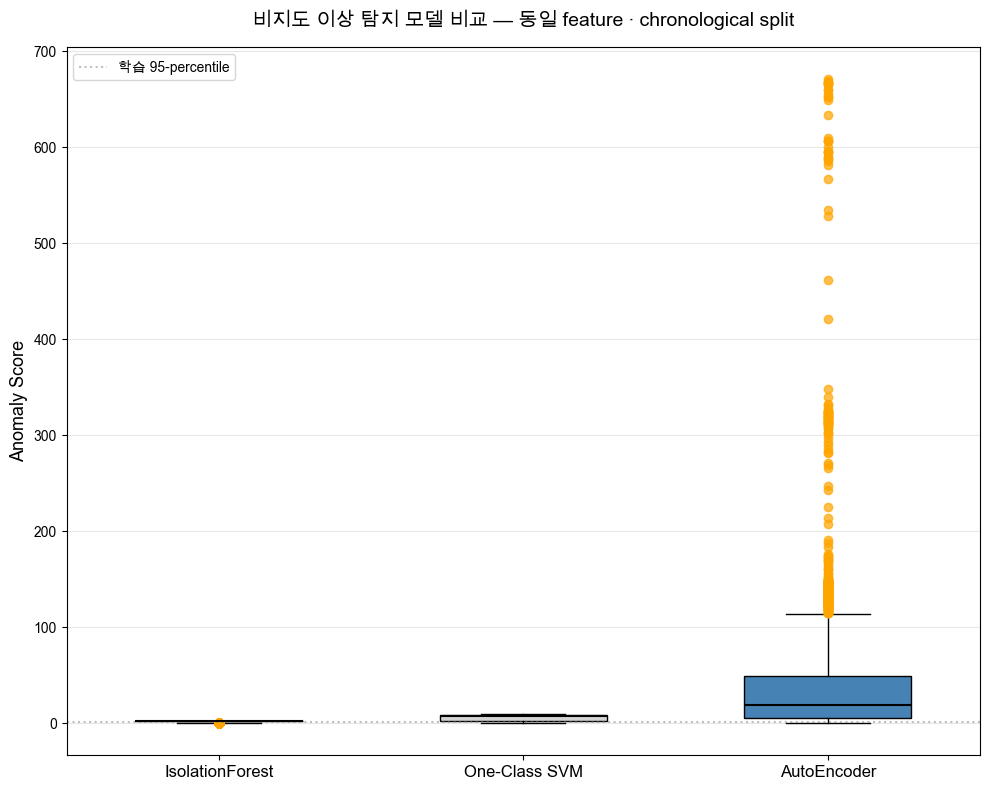

저장: notebooks/model_comparison_boxplot.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 8))

data = [norm_iso, norm_ocsvm, norm_ae]
labels = ['IsolationForest', 'One-Class SVM', 'AutoEncoder']
colors = ['lightgray', 'lightgray', 'steelblue']

bp = ax.boxplot(
    data, labels=labels,
    patch_artist=True, widths=0.55,
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=6,
                    markeredgecolor='orange', alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

# 학습 분포 기준선 (1.0)
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='학습 95-percentile')

ax.set_ylabel('Anomaly Score', fontsize=13)
ax.set_title('비지도 이상 탐지 모델 비교 — 동일 feature · chronological split', fontsize=14, pad=15)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'model_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: notebooks/model_comparison_boxplot.png')


## 7. 해석

| 모델 | 특징 | 한계 |
|---|---|---|
| **IsolationForest** | 빠름, 튜닝 간편 | 분포 좁음 → Caution/Warning/Critical 단계 구분 어려움 |
| **One-Class SVM** | 비선형 분리 가능 | 학습 느림(O(n²)), 커널·nu 튜닝 민감, 역시 분포 좁음 |
| **AutoEncoder** | 동적 범위 큼 → 임계값 다단 설정 쉬움, **피처별 reconstruction error로 RCA 분해 가능** | 학습 시간·GPU 선호 |

**결론**: AE는 단순히 '정상/이상' 이진 판정을 넘어, **점수의 크기로 심각도를 구간화**할 수 있고, 각 피처의 기여도까지 풀어낼 수 있어 현장 운영에 가장 적합했습니다.